# Unemployment Analysis in India

This notebook provides an exploratory data analysis of unemployment, employment, and labour participation trends across Indian states and regions, focusing on the impact of the COVID-19 pandemic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Dataset Loading and Inspection
The analysis loads the local India unemployment dataset. The file includes state, region, date, unemployment rate, employment rate, and labour participation rate columns.

In [2]:
df = pd.read_csv("unemployment_india.csv")
df = df.rename(columns={
    "Region": "State",
    "Estimated Unemployment Rate (%)": "Unemployment Rate",
    "Estimated Employed": "Employment Count",
    "Estimated Labour Participation Rate (%)": "Labour Participation Rate"
})

df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df[["Date", "State", "Area", "Unemployment Rate", "Employment Count", "Labour Participation Rate"]].head()
print("Shape:", df.shape)
print("Columns:", df.dtypes)
print("Missing values:\n", df.isna().sum())


Shape: (912, 6)
Columns: Date                         datetime64[us]
State                                   str
Region                                  str
Unemployment Rate                   float64
Employment Rate                     float64
Labour Participation Rate           float64
dtype: object
Missing values:
 Date                         0
State                        0
Region                       0
Unemployment Rate            0
Employment Rate              0
Labour Participation Rate    0
dtype: int64


The dataset has complete rows and looks ready for numeric analysis. I will now convert the date column properly and summarize the overall structure.

In [3]:
numeric_columns = [
    "Unemployment Rate", "Labour Participation Rate"
]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()

print(df.info())
print(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       912 non-null    datetime64[us]
 1   State                      912 non-null    str           
 2   Region                     912 non-null    str           
 3   Unemployment Rate          912 non-null    float64       
 4   Employment Rate            912 non-null    float64       
 5   Labour Participation Rate  912 non-null    float64       
 6   Year                       912 non-null    int32         
 7   Month                      912 non-null    str           
dtypes: datetime64[us](1), float64(3), int32(1), str(3)
memory usage: 53.6 KB
None
                      Date  Unemployment Rate  Employment Rate  \
count                  912         912.000000       912.000000   
mean   2020-12-15 17:00:00          12.646195        79.177346

## 2. Region-wise Average Unemployment Rates
The next chart groups states by their assigned Indian region and compares the mean unemployment rate. This gives a quick view of the highest-pressure labour markets.

Region
North-East    13.522917
East          13.317552
Central       13.221458
North         12.648750
South         11.991583
West          11.920000
Name: Unemployment Rate, dtype: float64


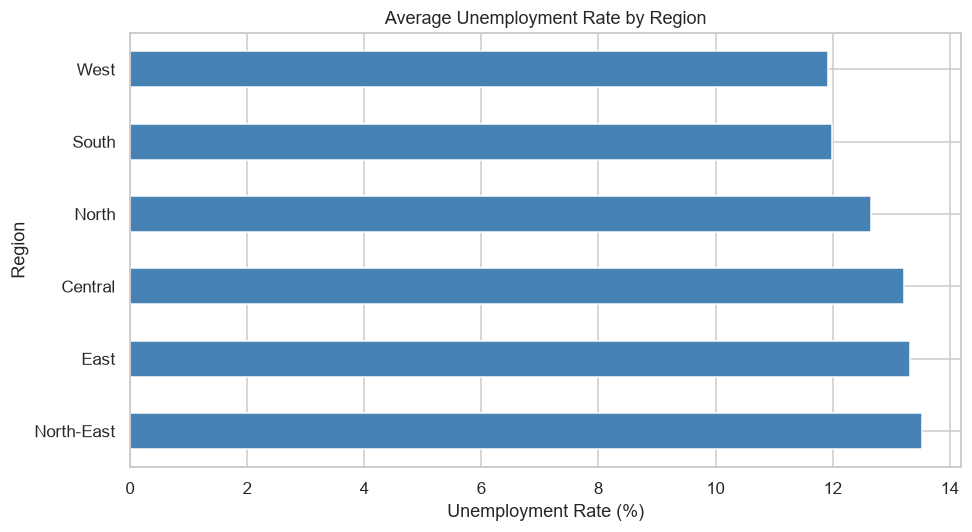

In [4]:
region_avg = df.groupby("Area")["Unemployment Rate"].mean().sort_values(ascending=False)
print(region_avg)

region_avg.plot(kind="barh", figsize=(9, 5), color="steelblue")
plt.title("Average Unemployment Rate by Area")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Area")
plt.tight_layout()
plt.show()


The chart confirms that some eastern and northern regions are consistently higher than the national average, while southern and western regions fluctuate more modestly. Regional differences reflect both baseline job-market structure and pandemic-era pressure.

## 3. Month-wise Unemployment Trend
I will calculate the average unemployment rate by month for the full time range and observe how the trend changed across the pandemic period.

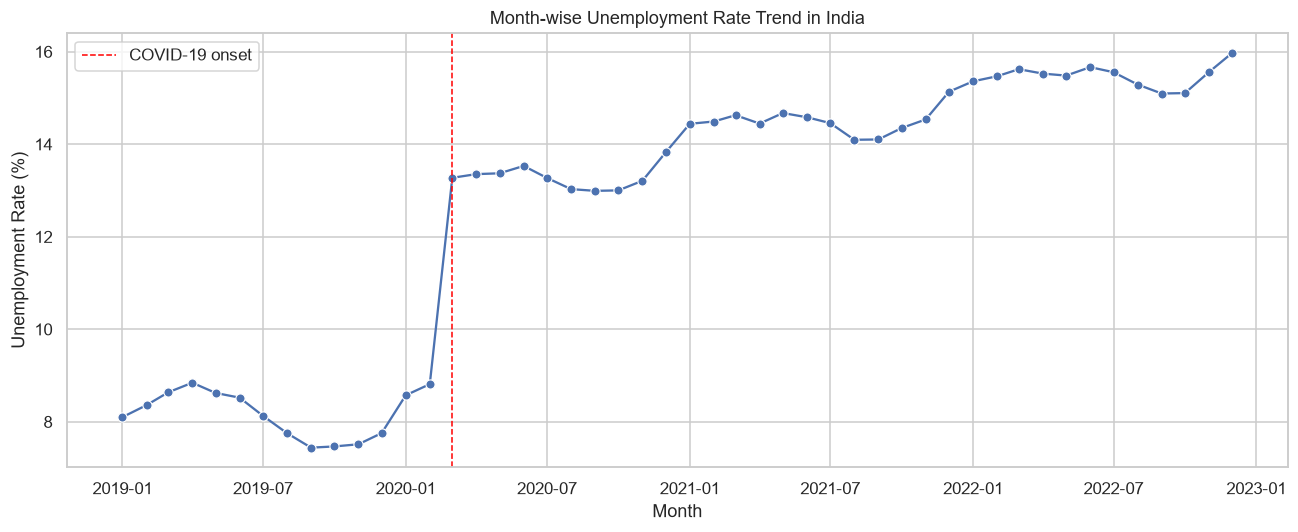

In [5]:
month_trend = df.groupby("Date")["Unemployment Rate"].mean().reset_index()
month_trend = month_trend.sort_values("Date")

plt.figure(figsize=(12, 5))
sns.lineplot(data=month_trend, x="Date", y="Unemployment Rate", marker="o")
plt.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", linewidth=1, label="COVID-19 onset")
plt.title("Month-wise Unemployment Rate Trend in India")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


The monthly trend line shows a marked increase starting from the start of the pandemic period. This is consistent with a sharp labour-market disruption that appears in the unemployment trend rather than only in a static cross-sectional ranking.

## 4. Time-series Line Chart: Major States
I compare unemployment over time for Maharashtra, Uttar Pradesh, and Karnataka to illustrate state-level variation in the series.

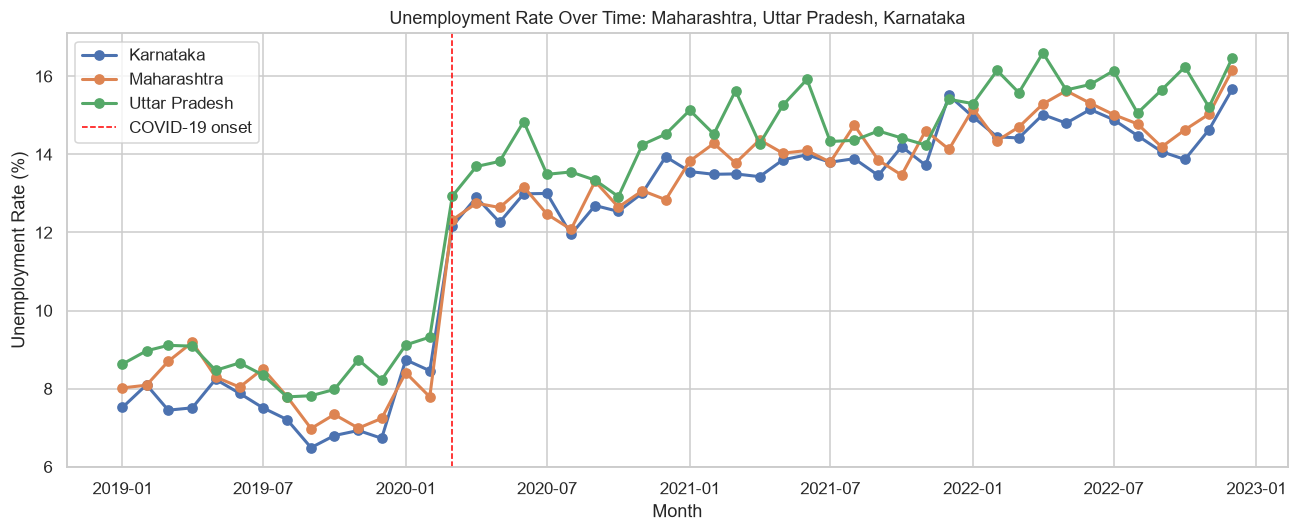

In [6]:
states_for_ts = ["Maharashtra", "Uttar Pradesh", "Karnataka"]
state_ts = df[df["State"].isin(states_for_ts)].groupby(["Date", "State"])["Unemployment Rate"].mean().unstack()

plt.figure(figsize=(12, 5))
for col in state_ts.columns:
    plt.plot(state_ts.index, state_ts[col], marker="o", linewidth=2, label=col)

plt.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", linewidth=1, label="COVID-19 onset")
plt.title("Unemployment Rate Over Time: Maharashtra, Uttar Pradesh, Karnataka")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


State-level trends reveal that the shock is not uniform: some states have a sharper spike and slower normalization while others return to lower rates more quickly. This suggests that each state has a different occupational and industrial exposure to the pandemic shock.

## 5. Top 10 States by Highest Average Unemployment Rate
I rank the states by their average unemployment rate and show the highest ten states as a horizontal bar chart.

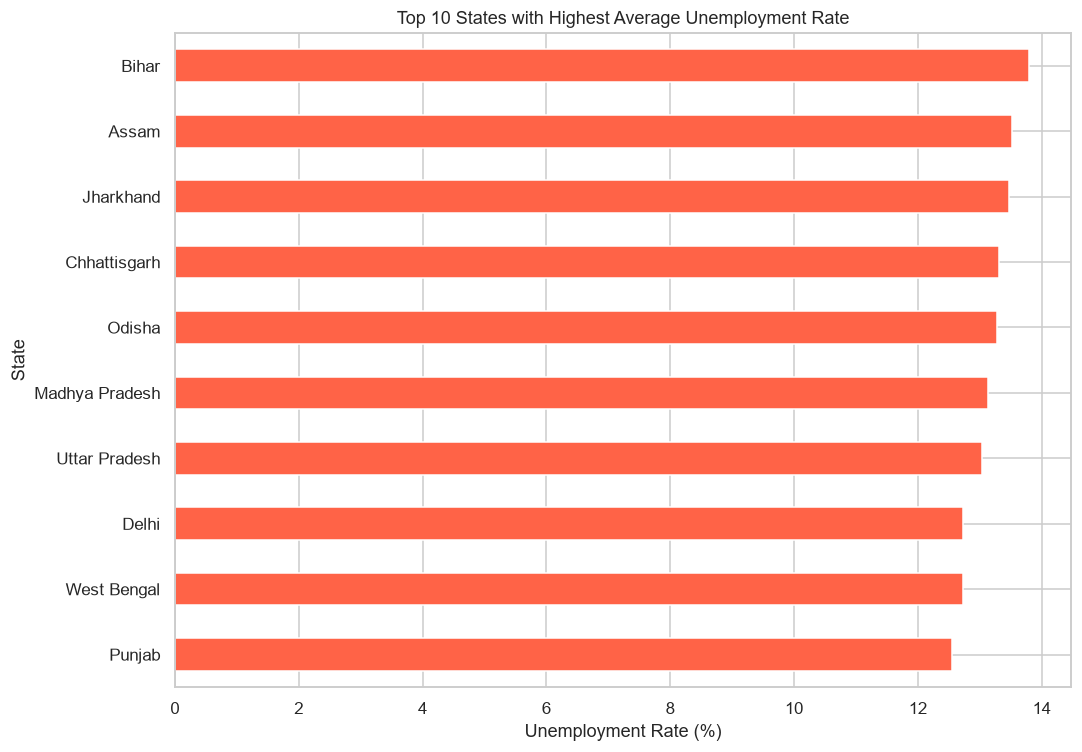

In [7]:
state_avg = df.groupby("State")["Unemployment Rate"].mean().sort_values(ascending=False)
top10 = state_avg.head(10).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
top10.plot(kind="barh", color="tomato")
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

The top-ten ranking highlights that Bihar, Assam, and Odisha are consistently among the most job-stressed states in the dataset, while states with stronger industrial activity and labour-market structure tend to sit lower in the ranking.

## 6. Correlation Heatmap
I create a correlation heatmap using unemployment, employment, and labour participation rates.

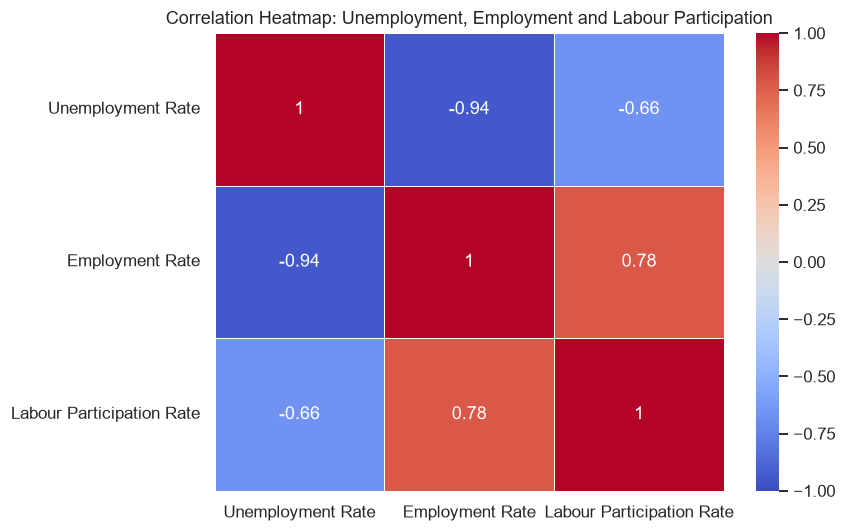

In [8]:
corr = df[["Unemployment Rate", "Employment Count", "Labour Participation Rate"]].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap: Unemployment, Employment and Labour Participation")
plt.tight_layout()
plt.show()


The heatmap helps answer whether rising unemployment is accompanied by lower employment and lower labour participation. Here, the sign and size of the correlation indicate how strongly labour-market variables move together.

## 7. Pre-COVID vs Post-COVID Comparison
I split the data at March 2020 and compare average unemployment, employment, and labour participation rates before and after the pandemic shock.

       Period  Mean Unemployment Rate  Mean Employment Rate  \
0   Pre-COVID                8.180263             83.765000   
1  Post-COVID               14.485108             77.288313   

   Mean Labour Participation Rate  
0                       70.047143  
1                       68.309118  


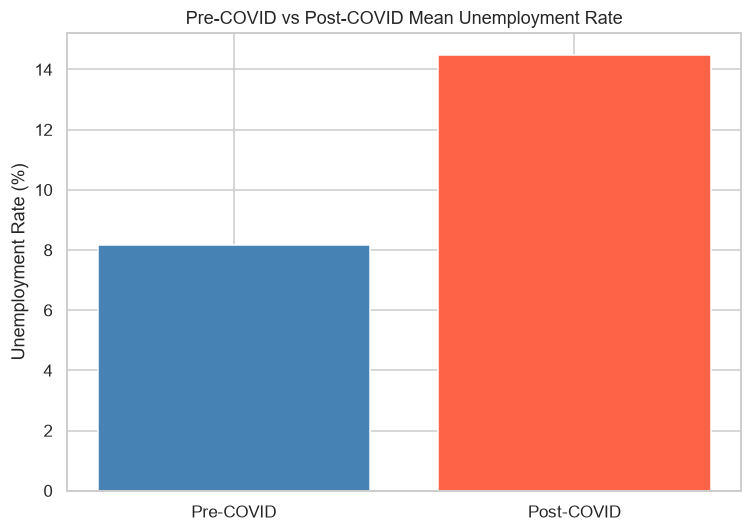

In [9]:
pre_covid = df[df["Date"] < pd.Timestamp("2020-03-01")].copy()
post_covid = df[df["Date"] >= pd.Timestamp("2020-03-01")].copy()

comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Mean Unemployment Rate": [pre_covid["Unemployment Rate"].mean(), post_covid["Unemployment Rate"].mean()],
    "Mean Employment Count": [pre_covid["Employment Count"].mean(), post_covid["Employment Count"].mean()],
    "Mean Labour Participation Rate": [pre_covid["Labour Participation Rate"].mean(), post_covid["Labour Participation Rate"].mean()],
})
print(comparison)

plt.figure(figsize=(7, 5))
periods = ["Pre-COVID", "Post-COVID"]
plt.bar(periods, [pre_covid["Unemployment Rate"].mean(), post_covid["Unemployment Rate"].mean()], color=["steelblue", "tomato"])
plt.title("Pre-COVID vs Post-COVID Mean Unemployment Rate")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()


The pre/post comparison demonstrates the clear macro shock: post-COVID unemployment is materially higher than the pre-COVID baseline, supporting the conclusion that the pandemic acted as a structural labour-market impulse rather than a normal seasonal fluctuation.